# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_excel('titanic.xlsx')
train.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1349 non-null   int64  
 1   survived   1349 non-null   int64  
 2   name       1349 non-null   object 
 3   sex        1349 non-null   object 
 4   age        1076 non-null   float64
 5   sibsp      1349 non-null   int64  
 6   parch      1349 non-null   int64  
 7   ticket     1349 non-null   object 
 8   fare       1348 non-null   float64
 9   cabin      296 non-null    object 
 10  embarked   1347 non-null   object 
 11  boat       487 non-null    object 
 12  body       129 non-null    float64
 13  home.dest  748 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 147.7+ KB


In [4]:
d = train.describe()
d

,pclass,survived,age,sibsp,parch,fare,body
count,1349.000000,1349.000000,1076.000000,1349.000000,1349.000000,1348.000000,129.000000
mean,2.313566,0.372128,29.920694,0.495923,0.376575,32.699242,166.000000
std,0.834334,0.483551,14.316625,1.033284,0.857287,51.142048,100.265429
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,75.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.427100,165.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,30.548950,260.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


<Axes: xlabel='survived', ylabel='count'>

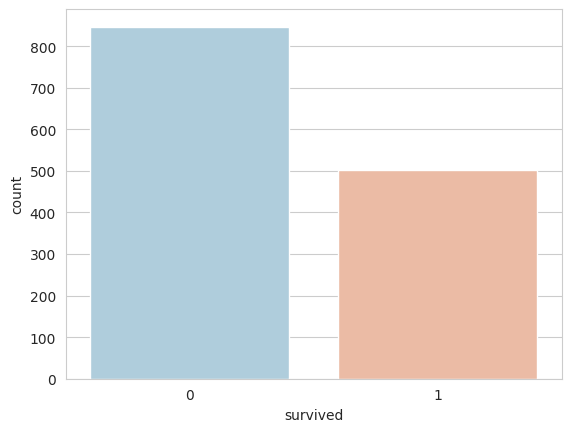

In [5]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='survived', hue='survived', data=train, palette='RdBu_r', legend=False)

<Axes: xlabel='survived', ylabel='count'>

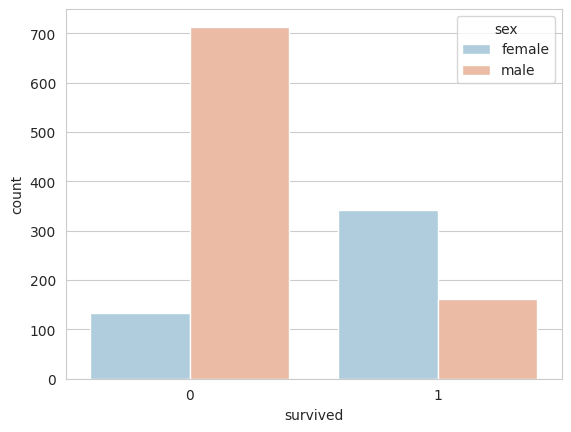

In [6]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='survived',hue='sex',data=train,palette='RdBu_r')

<Axes: xlabel='survived', ylabel='count'>

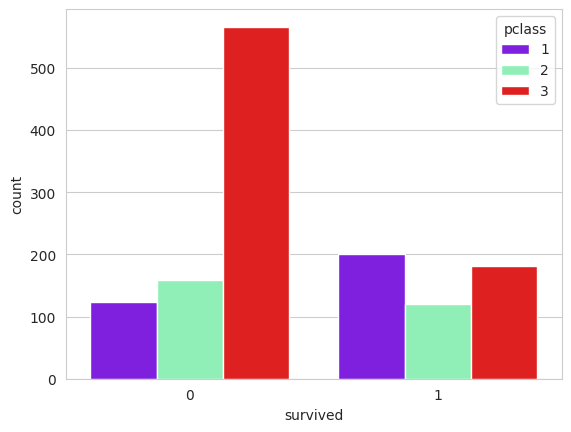

In [7]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.countplot(x='survived',hue='pclass',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase penumpang yang selamat berdasarkan kelas')

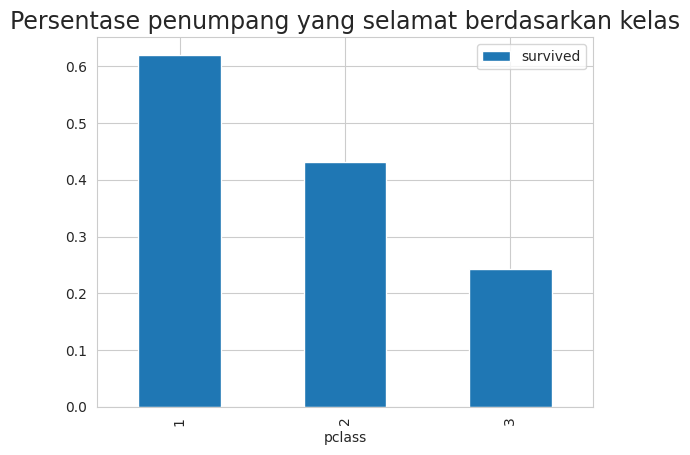

In [8]:
f_class_survived=train.groupby('pclass')['survived'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived
f_class_survived.plot.bar(y='survived')
plt.title("Persentase penumpang yang selamat berdasarkan kelas",fontsize=17)

<Axes: xlabel='survived', ylabel='count'>

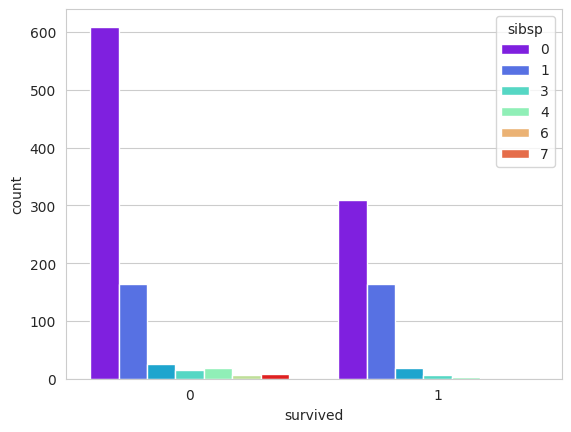

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='survived',hue='sibsp',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram usia penumpang'}, xlabel='Usia penumpang', ylabel='Count'>

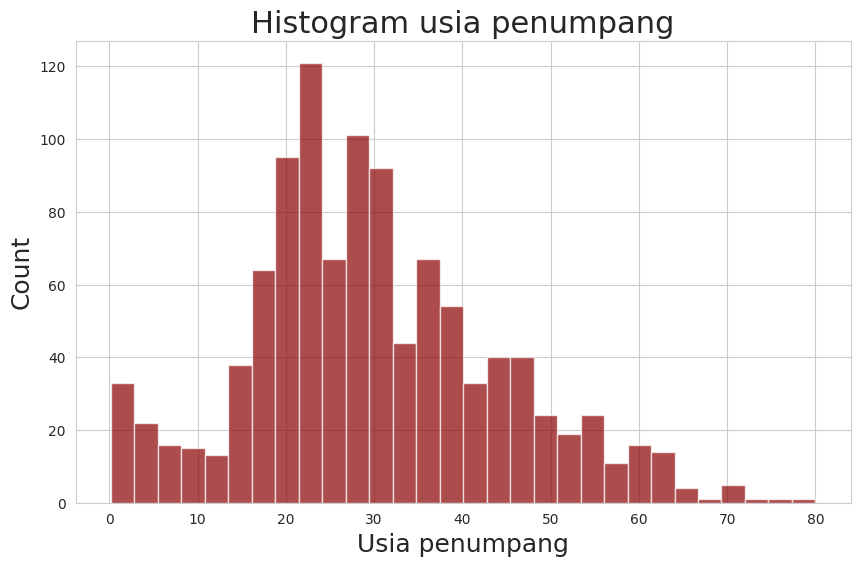

In [ ]:
# Cek distribusi dari umur
plt.xlabel("Usia penumpang",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia penumpang",fontsize=22)
train['age'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

<Axes: xlabel='Passenger Class', ylabel='Age'>

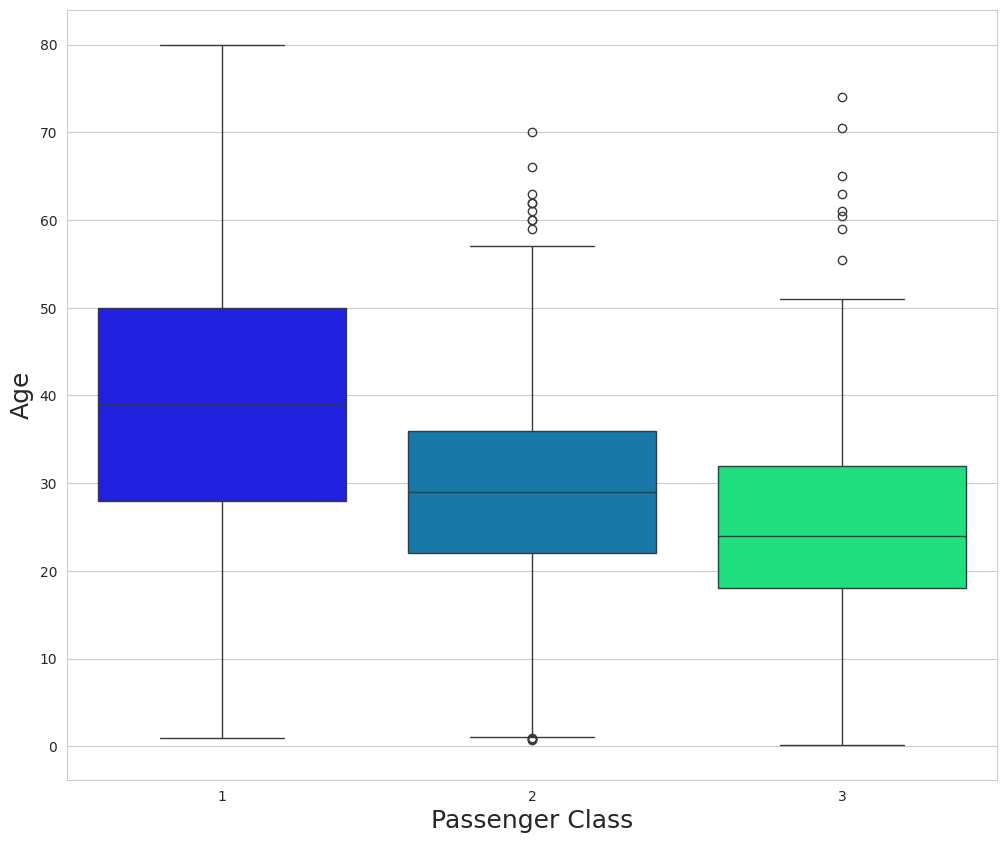

In [9]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Passenger Class",fontsize=18)
plt.ylabel("Age",fontsize=18)
sns.boxplot(x='pclass',y='age',data=train,palette='winter', hue='pclass', legend=False)

Text(0.5, 0, 'Passenger class')

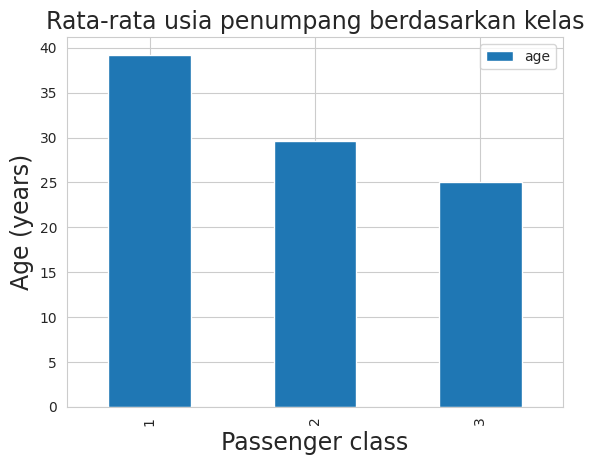

In [10]:
f_class_Age=train.groupby('pclass')['age'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='age')
plt.title("Rata-rata usia penumpang berdasarkan kelas",fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Passenger class", fontsize=17)

### Fitur Engineering

In [11]:
a=list(f_class_Age['age'])

def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return a[0]

        elif Pclass == 2:
            return a[1]

        else:
            return a[2]

    else:
        return Age

In [12]:
train['age'] = train[['age', 'pclass']].apply(impute_age, axis=1)

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

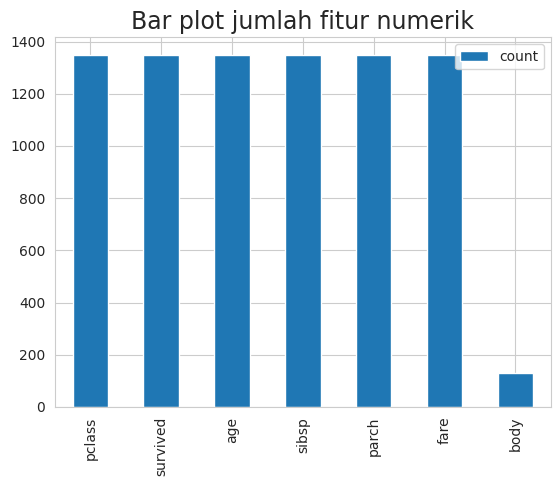

In [13]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [14]:
train = pd.read_excel('titanic.xlsx')
# Apply the age imputation again as reloading the data will reset 'age' column
a=list(f_class_Age['age'])
def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return a[0]
        elif Pclass == 2:
            return a[1]
        else:
            return a[2]
    else:
        return Age
train['age'] = train[['age', 'pclass']].apply(impute_age, axis=1)

# Drop columns with too many null values
train.drop(['cabin', 'boat', 'body', 'home.dest'], axis=1, inplace=True)
# Now, handle the remaining few nulls (e.g., in 'fare' and 'embarked') by dropping rows
train.dropna(inplace=True)
train.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S


In [15]:
# Drop semua kolom yang tidak penting
train.drop(['name','ticket'],axis=1,inplace=True)
train.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['sex'] = le.fit_transform(train['sex'])
train['embarked'] = le.fit_transform(train['embarked'])
train.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,0,29.0000,0,0,211.3375,2
1,1,1,1,0.9167,1,2,151.5500,2
2,1,0,0,2.0000,1,2,151.5500,2
3,1,0,1,30.0000,1,2,151.5500,2
4,1,0,0,25.0000,1,2,151.5500,2


### Training

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('survived',axis=1),
                                                    train['survived'], test_size=0.30,
                                                    random_state=42)

In [18]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (942, 7)
Test shape: (404, 7)


# **KNN**

In [19]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [20]:
y_pred = clf1.predict(X_test)

### Evaluation

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.64
Confusion Matrix:
[[199  56]
 [ 89  60]]
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       255
           1       0.52      0.40      0.45       149

    accuracy                           0.64       404
   macro avg       0.60      0.59      0.59       404
weighted avg       0.63      0.64      0.63       404



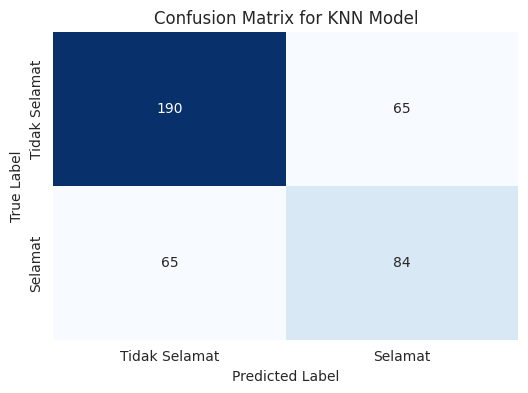

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Model')
plt.show()

# **Naive Bayes**

In [22]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.78
Confusion Matrix:
[[215  40]
 [ 47 102]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       255
           1       0.72      0.68      0.70       149

    accuracy                           0.78       404
   macro avg       0.77      0.76      0.77       404
weighted avg       0.78      0.78      0.78       404



# **Decision Tree**

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.74
Confusion Matrix:
[[208  47]
 [ 58  91]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       255
           1       0.66      0.61      0.63       149

    accuracy                           0.74       404
   macro avg       0.72      0.71      0.72       404
weighted avg       0.74      0.74      0.74       404



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [27]:
# Data penumpang baru
# Format: [Pclass, Sex (0=female, 1=male), Age, SibSp, Parch, Fare, Embarked (0=C, 1=Q, 2=S)]
new_data = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi kelas
new_prediction = nb.predict(new_data)
print("Prediksi Kelangsungan Hidup (0 = Tidak Selamat, 1 = Selamat):", new_prediction[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas Prediksi [Tidak Selamat, Selamat]:", proba[0])

Prediksi Kelangsungan Hidup (0 = Tidak Selamat, 1 = Selamat): 0
Probabilitas Prediksi [Tidak Selamat, Selamat]: [0.51063266 0.48936734]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [28]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.64
Confusion Matrix:
[[191  64]
 [ 82  67]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       255
           1       0.51      0.45      0.48       149

    accuracy                           0.64       404
   macro avg       0.61      0.60      0.60       404
weighted avg       0.63      0.64      0.63       404



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.720798   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.720838   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.721873   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.720815   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.718716   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.717607   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.716554   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.716565   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.712304   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.713402   
1   {'metric': 'euclidean', 'n_neighbors

In [31]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [32]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [33]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.68
Presisi:  0.65
Recall:   0.65
F1-Score: 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       255
           1       0.56      0.56      0.56       149

    accuracy                           0.68       404
   macro avg       0.65      0.65      0.65       404
weighted avg       0.68      0.68      0.68       404

Confusion Matrix:
[[190  65]
 [ 65  84]]


In [34]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data_1 = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
